### EQUILIBRIUM ANALYSIS, RMSF and then RMSD, Salt bridge formation, DFG flip

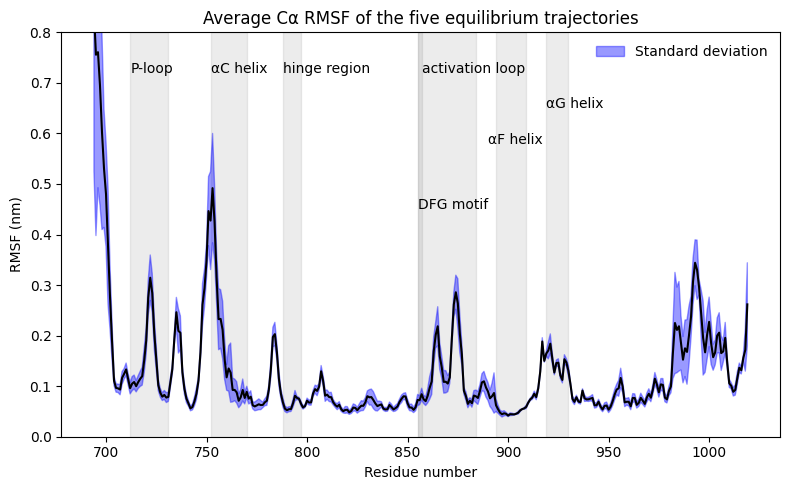

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator #for ease of axis scaling
import numpy as np

numbered_cas = np.arange(694, 1020, 1)

fluc_dic = {}
fluc_columns = ["residue", "fluctuations"]
for n in range(1, 6):
    filename = f"EQ_RMSF_RMSD/rmsf/numerical_ca_{n}_RMSF.txt"
    rmsf_df = pd.read_csv(filename,  sep='\s+', comment='@', header=None)
    rmsf_df.columns = fluc_columns
    fluc_dic[f"{n}_fluc_df"] = rmsf_df


colors = ["violet", "purple", "crimson", "darkviolet", "darkslateblue"]

av_fluc = (fluc_dic["1_fluc_df"] + fluc_dic["2_fluc_df"] + fluc_dic["3_fluc_df"] + fluc_dic["4_fluc_df"] + fluc_dic["5_fluc_df"])/5

std_fluc_list = np.std(
    np.column_stack(
        [fluc_dic[f"{i}_fluc_df"]["fluctuations"] for i in range(1, 6)]
    ),
    axis=1
).tolist()
std_series = pd.Series(std_fluc_list)


plt.figure(figsize=(8,5))
plt.plot(av_fluc["residue"], av_fluc["fluctuations"], color = "black")
plt.fill_between(
    av_fluc["residue"],
    av_fluc["fluctuations"] - std_series,
    av_fluc["fluctuations"] + std_series,
    alpha=0.4,
    color="blue",
    label="Standard deviation"
)

plt.title("Average Cα RMSF of the five equilibrium trajectories")
plt.xlabel("Residue number")
plt.ylabel("RMSF (nm)")
plt.legend(loc=1, frameon=False)
plt.ylim(0, 0.8)
plt.tight_layout()


ax = plt.gca()
ax.axvspan(712, 731, alpha=0.15, color="grey", zorder=0)
ax.text(712, 0.72, "P-loop" )

ax.axvspan(752, 770, alpha=0.15, color="grey", zorder=0)
ax.text(752, 0.72, "αC helix" )

ax.axvspan(855, 884, alpha=0.15, color="grey", zorder=0)
ax.text(857, 0.72, "activation loop" )

ax.axvspan(788, 797, alpha=0.15, color="grey", zorder=0)
ax.text(788, 0.72, "hinge region")

ax.axvspan(855, 857, alpha=0.15, color="grey", zorder=0)
ax.text(855, 0.45, "DFG motif")

ax.axvspan(894, 909, alpha=0.15, color="grey", zorder=0)
ax.text(890, 0.58, "αF helix")

ax.axvspan(919, 930, alpha=0.15, color="grey", zorder=0)
ax.text(919, 0.65, "αG helix")

plt.savefig("eq_rmsfsquare.png")

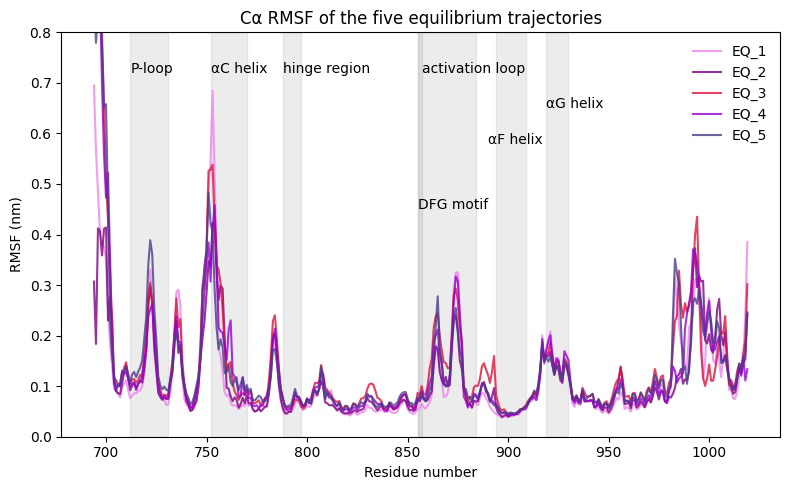

In [72]:

plt.figure(figsize=(8,5))

colors = ["violet", "purple", "crimson", "darkviolet", "darkslateblue"]
k = 60

for n, c in enumerate(colors, start=1):
    df = fluc_dic[f"{n}_fluc_df"]

    res = df["residue"]
    rmsf  = df["fluctuations"]

    plt.plot(res, rmsf, color=c, alpha = 0.8, label=f"EQ_{n}")

plt.title("Cα RMSF of the five equilibrium trajectories")
plt.xlabel("Residue number")
plt.ylabel("RMSF (nm)")
plt.legend(loc=1, frameon=False)
plt.gca().xaxis.set_major_locator(MultipleLocator(50))
plt.ylim(0, 0.8)
plt.tight_layout()

ax = plt.gca()
ax.axvspan(712, 731, alpha=0.15, color="grey", zorder=0)
ax.text(712, 0.72, "P-loop" )

ax.axvspan(752, 770, alpha=0.15, color="grey", zorder=0)
ax.text(752, 0.72, "αC helix" )

ax.axvspan(855, 884, alpha=0.15, color="grey", zorder=0)
ax.text(857, 0.72, "activation loop" )

ax.axvspan(788, 797, alpha=0.15, color="grey", zorder=0)
ax.text(788, 0.72, "hinge region")

ax.axvspan(855, 857, alpha=0.15, color="grey", zorder=0)
ax.text(855, 0.45, "DFG motif")

ax.axvspan(894, 909, alpha=0.15, color="grey", zorder=0)
ax.text(890, 0.58, "αF helix")

ax.axvspan(919, 930, alpha=0.15, color="grey", zorder=0)
ax.text(919, 0.65, "αG helix")

plt.savefig("eq_rmsf_allruns.png")

In [3]:
av_fluc.iloc[72]

residue         766.00000
fluctuations      0.07112
Name: 72, dtype: float64

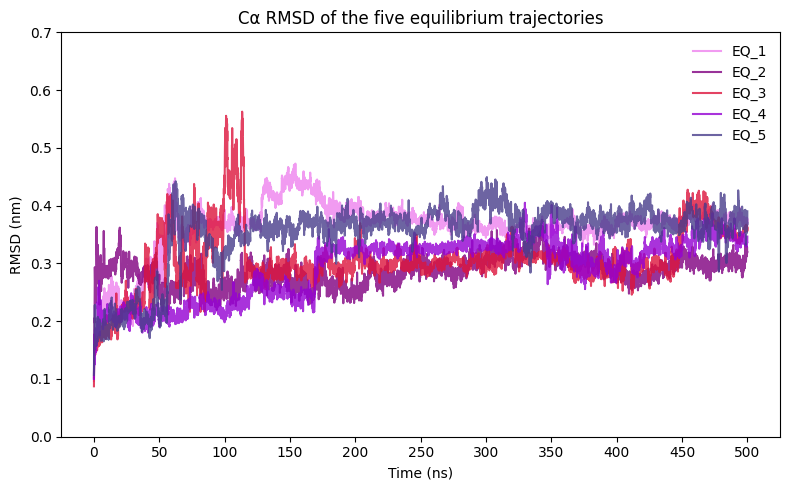

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

numbered_cas = np.arange(694, 1020, 1)


diff_dic = {}
diff_columns = ["time (ps)", "RMSD"]
for n in range(1, 6):
    filename = f"EQ_RMSF_RMSD/rmsd/numerical_ca_{n}_RMSD.txt"
    diff_df = pd.read_csv(filename,  sep='\s+', comment='@', header=None)
    diff_df.columns = diff_columns
    diff_dic[f"{n}_diff_df"] = diff_df


# plt.figure(figsize=(12,6))
# #colors = ["olivedrab", "yellowgreen", "darkolivegreen", "greenyellow", "chartreuse"]
# colors = ["violet", "purple", "crimson", "darkviolet", "darkslateblue"]

# k = 60

# for n, c in enumerate(colors, start = 1):
#     plt.plot(diff_dic[f"{n}_diff_df"]["time (ps)"].groupby(diff_df.index // k).mean(), diff_dic[f"{n}_diff_df"]["RMSD"].groupby(diff_df.index // k).mean(), color = c, label = f"EQ_{n}")
#     plt.title("RMSD alpha carbon(WORK IN PROGRESS)")
#     plt.legend(loc=1)
#     plt.ylim(0, 0.6)



plt.figure(figsize=(8,5))

colors = ["violet", "purple", "crimson", "darkviolet", "darkslateblue"]
k = 60

for n, c in enumerate(colors, start=1):
    df = diff_dic[f"{n}_diff_df"]

    t_ns = (df["time (ps)"] / 1000).groupby(df.index // k).mean()
    rmsd  = df["RMSD"].groupby(df.index // k).mean()

    plt.plot(t_ns, rmsd, color=c, alpha = 0.8, label=f"EQ_{n}")

plt.title("Cα RMSD of the five equilibrium trajectories")
plt.xlabel("Time (ns)")
plt.ylabel("RMSD (nm)")
plt.legend(loc=1, frameon=False)
plt.gca().xaxis.set_major_locator(MultipleLocator(50))
plt.ylim(0, 0.7)
plt.tight_layout()



# ax = plt.gca()
# ax.axvspan(50, 425, alpha=0.2, color="grey", zorder=0)
# ax.text(
#     50,      
#     0.65,    
#     "Nonequilibrium simulation period",
#     fontsize=11,
#     color="black",
#     alpha=0.8
# )

plt.savefig("eq_rmsd.png")

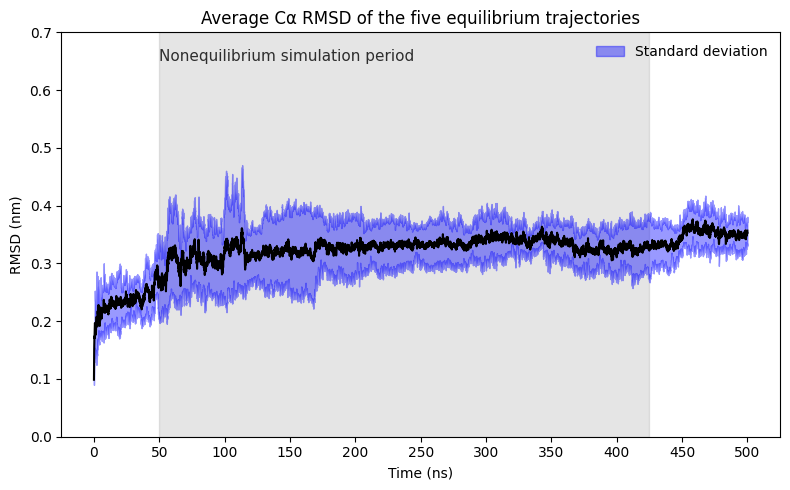

In [71]:
#Making an average dataframe for the rmsd

av_diff = (diff_dic["1_diff_df"] + diff_dic["2_diff_df"] + diff_dic["3_diff_df"] + diff_dic["4_diff_df"] + diff_dic["5_diff_df"])/5
#Some black magic to make sure the standard deviation can be processed like time and rmsd
std_list = np.std(
    np.column_stack(
        [diff_dic[f"{i}_diff_df"]["RMSD"] for i in range(1, 6)]
    ),
    axis=1
).tolist()
std_series = pd.Series(std_list)

k = 60 
t_ns = (av_diff["time (ps)"] / 1000).groupby(av_diff.index // k).mean()
rmsd  = av_diff["RMSD"].groupby(av_diff.index // k).mean()
resampledstd = std_series.groupby(av_diff.index // k).mean()

plt.figure(figsize=(8,5))

plt.plot(t_ns, rmsd, color = "black")
plt.fill_between(t_ns, rmsd - resampledstd, rmsd + resampledstd, alpha=0.4, color="blue", label = "Standard deviation")


# for n, c in enumerate(colors, start=1):
#     df = diff_dic[f"{n}_diff_df"]

#     t_ns = (df["time (ps)"] / 1000).groupby(df.index // k).mean()
#     rmsd  = df["RMSD"].groupby(df.index // k).mean()

#     plt.plot(t_ns, rmsd, color=c, alpha = 0.2, label=f"EQ_{n}")

plt.title("αC RMSD of the five equilibrium trajectories")
plt.xlabel("Time (ns)")
plt.ylabel("RMSD (nm)")
plt.legend(loc=1, frameon=False)
plt.gca().xaxis.set_major_locator(MultipleLocator(50))

plt.title("Average Cα RMSD of the five equilibrium trajectories")
plt.xlabel("Time (ns)")
plt.ylabel("RMSD (nm)")

ax = plt.gca()
ax.axvspan(50, 425, alpha=0.2, color="grey", zorder=0)
ax.text(
    50,      
    0.65,    
    "Nonequilibrium simulation period",
    fontsize=11,
    color="black",
    alpha=0.8
)
plt.ylim(0, 0.7)
plt.tight_layout()
plt.savefig("Averagermsd.png")


### Salt bridge analysis


In [57]:
filename_sb_full = "SALTBRIDGE/numericalsaltbridge430.txt"
sb_df_full = pd.read_csv(filename_sb_full, sep='\s+', comment='@', header=None)


filename_sb_776 = "SALTBRIDGE/numerical_saltbridge_776.txt"
sb_df_776 = pd.read_csv(filename_sb_776, sep='\s+', comment='@', header=None)

filename_sb_768 = "SALTBRIDGE/numerical_saltbridge_768.txt"
sb_df_768 = pd.read_csv(filename_sb_768, sep='\s+', comment='@', header=None)

filename_sb_718 = "SALTBRIDGE/numerical_saltbridge_718.txt"
sb_df_718 = pd.read_csv(filename_sb_718, sep='\s+', comment='@', header=None)

filename_sb_861 = "SALTBRIDGE/numerical_saltbridge_861.txt"
sb_df_861 = pd.read_csv(filename_sb_861, sep='\s+', comment='@', header=None)

zoombeginning, zoomending = 1370000, 1520000

interest_zoom = (sb_df_full[0] > zoombeginning) & (sb_df_full[0] < zoomending)
Run_4 = (sb_df_full[0] > 1140000) & (sb_df_full[0] < 1520000)


In [58]:
interest_zoom_size = zoomending - zoombeginning
interest_zoom_size



150000

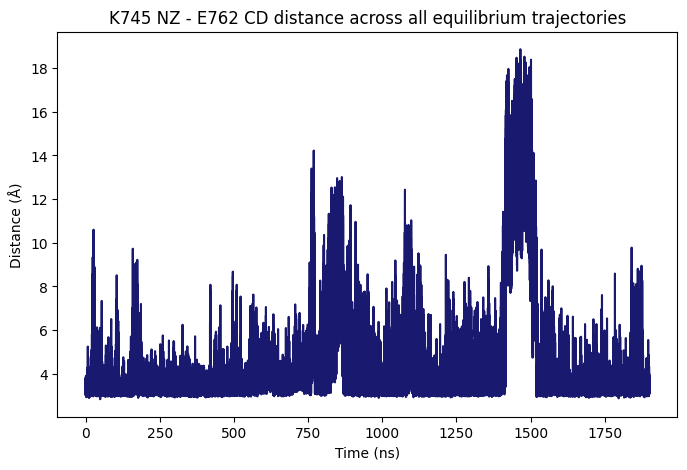

In [59]:
plt.figure(figsize=(8,5))
plt.plot(sb_df_full[0]/1000, sb_df_full[1]*10, color = "midnightblue")
#plt.plot(sb_df_776[0]/1000, sb_df_776[1]*10, label = "776", alpha = 0.25)
# plt.plot(sb_df_768[0]/1000, sb_df_768[1]*10, label = "768", alpha = 0.5)
# plt.plot(sb_df_718[0]/1000, sb_df_718[1]*10, label = "718", alpha = 0.5)
# plt.plot(sb_df_861[0]/1000, sb_df_861[1]*10, label = "861", alpha = 0.5)


plt.title("K745 NZ - E762 CD distance across all equilibrium trajectories")
plt.xlabel("Time (ns)")
plt.ylabel("Distance (Å)")



#plt.legend()
plt.savefig("Saltbridgedistances_eq.png")



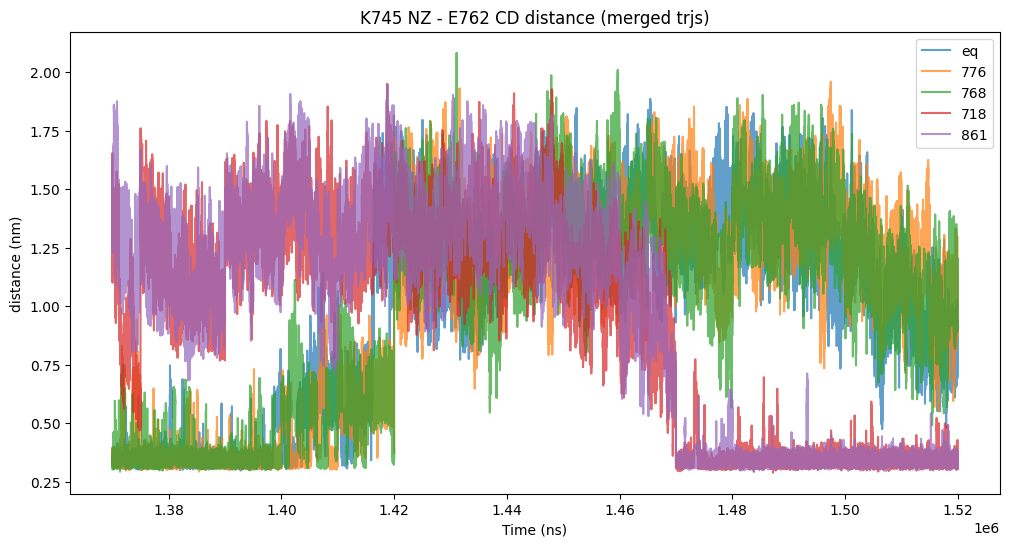

In [60]:
plt.figure(figsize=(12,6))
plt.plot(sb_df_full[0][interest_zoom], sb_df_full[1][interest_zoom], label = "eq", alpha = 0.7)
plt.plot(sb_df_776[0][interest_zoom], sb_df_776[1][interest_zoom], label = "776", alpha = 0.7)
plt.plot(sb_df_768[0][interest_zoom], sb_df_768[1][interest_zoom], label = "768", alpha = 0.7)
plt.plot(sb_df_718[0][interest_zoom], sb_df_718[1][interest_zoom], label = "718", alpha = 0.7)
plt.plot(sb_df_861[0][interest_zoom], sb_df_861[1][interest_zoom], label = "861", alpha = 0.7)

plt.title("K745 NZ - E762 CD distance (merged trjs)")
plt.xlabel("Time (ns)")
plt.ylabel("distance (nm)")



plt.legend()

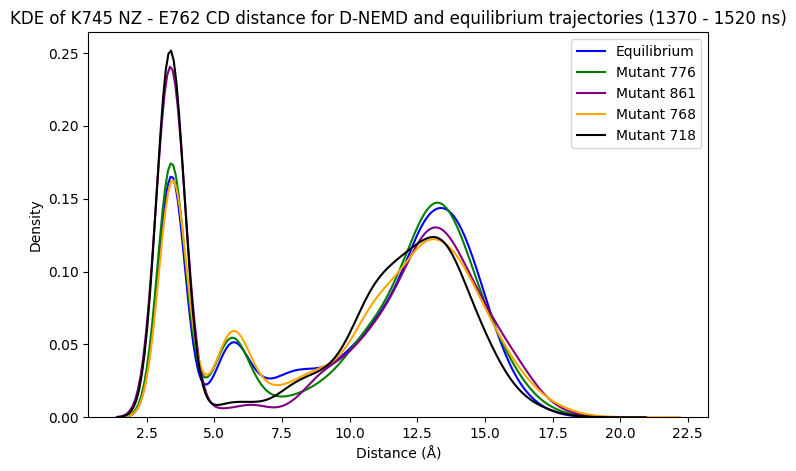

In [68]:
#%pip install seaborn
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(data=sb_df_full[1][interest_zoom]*10, color="blue", label = "Equilibrium")
sns.kdeplot(data=sb_df_776[1][interest_zoom]*10, color="green", label = "Mutant 776")
sns.kdeplot(data=sb_df_861[1][interest_zoom]*10, color="purple", label = "Mutant 861")
sns.kdeplot(data=sb_df_768[1][interest_zoom]*10, color="orange", label = "Mutant 768")
sns.kdeplot(data=sb_df_718[1][interest_zoom]*10, color="black", label = "Mutant 718")
# plt.xlim(0.2, 0.45)
plt.gca().xaxis.set_major_locator(MultipleLocator(2.5))
plt.xlabel("Distance (Å)")
plt.title("KDE of K745 NZ - E762 CD distance for D-NEMD and equilibrium trajectories (1370 - 1520 ns)")
plt.legend()
plt.savefig("KDE_Mutant_saltbridge.png")
plt.show()





#TINY EQ SHIFT IN 861, bigger in  718
#CHOP IT DOWN TO SHOW DISTANCES AT TIME 0, 2 ns, 5 ns

#DO THE DFG ANALYSIS

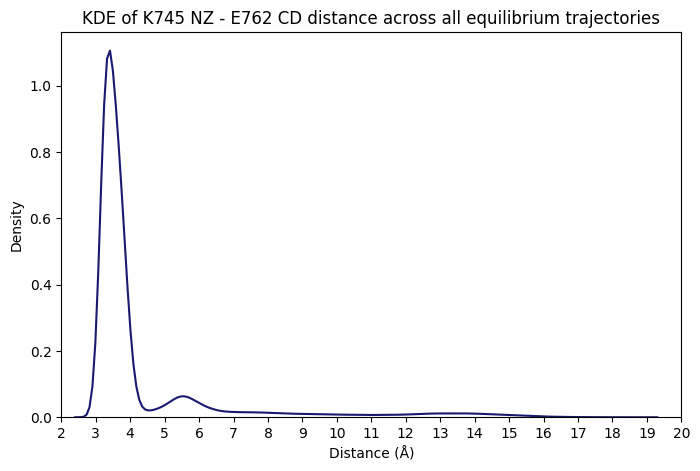

In [41]:

plt.figure(figsize=(8,5))
sns.kdeplot(data=sb_df_full[1]*10, color="midnightblue")

# sns.kdeplot(data=sb_df_776[1], color="green", label = "776")
# sns.kdeplot(data=sb_df_861[1], color="purple", label = "861")
plt.xlim(2, 20)
plt.title("KDE of K745 NZ - E762 CD distance across all equilibrium trajectories")
plt.xlabel("Distance (Å)")
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
#plt.legend()
plt.savefig("Saltbridgedistances_eq_KDE.png")
plt.show()
#NEED TO RUN A KERNEL DENSITY 

#### DFG ANALYSIS

In [12]:
filename_dfgeq = "dfgflip_mk2/dfgflipeq.txt"
dfg_dfeq = pd.read_csv(filename_dfgeq, sep='\s+', comment='@', header=None)

filename_dfg776 = "dfgflip_mk2/dfgflip776.txt"
dfg_df776 = pd.read_csv(filename_dfg776, sep='\s+', comment='@', header=None)

filename_dfg768 = "dfgflip_mk2/dfgflip768.txt"
dfg_df768 = pd.read_csv(filename_dfg768, sep='\s+', comment='@', header=None)


filename_dfg718 = "dfgflip_mk2/dfgflip718.txt"
dfg_df718 = pd.read_csv(filename_dfg718, sep='\s+', comment='@', header=None)

filename_dfg861 = "dfgflip_mk2/dfgflip861.txt"
dfg_df861 = pd.read_csv(filename_dfg861, sep='\s+', comment='@', header=None)

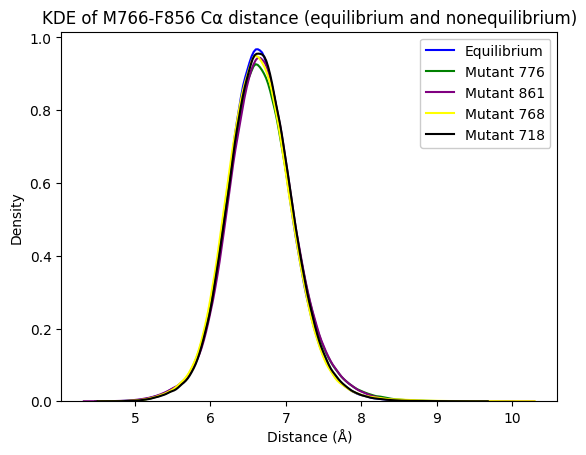

In [86]:

sns.kdeplot(data=dfg_dfeq[1]*10, color = "blue", label = "Equilibrium")

sns.kdeplot(data=dfg_df776[1]*10, color = "green", label = "Mutant 776")

sns.kdeplot(data=dfg_df861[1]*10, color = "purple", label = "Mutant 861")

sns.kdeplot(data=dfg_df768[1]*10, color = "yellow", label = "Mutant 768")

sns.kdeplot(data=dfg_df718[1]*10, color = "black",label = "Mutant 718")



# plt.axvline(x=6.7, linewidth=2, color = "green", label = "8SC7", alpha = 0.75)
# #plt.text(6.7, 0.65, "8SC7")

# plt.axvline(x=7.0, linewidth=2, color = "yellow", label = "2ITX", alpha = 0.75)
# #plt.text(7.0, 0.65, "2ITX")

# plt.axvline(x=11.6, linewidth=2, color = "mediumpurple", label = "5HG7", alpha = 0.75)
# #plt.text(11.6, 0.65, "5HG7")

# plt.axvline(x=10.6, linewidth=2, color = "orange", label = "4I1Z", alpha = 0.75)
# #plt.text(10.6, 0.65, "4I1Z")

plt.xlabel("Distance (Å)")
plt.title("KDE of M766-F856 Cα distance (equilibrium and nonequilibrium)")

legend = plt.legend(loc = "upper right", framealpha = 1.0 )
legend.get_frame().set_facecolor('white')
plt.savefig("Dfg_eq.png")

plt.show()


In [14]:
av_fluc

,residue,fluctuations
0,694.0,0.84114
1,695.0,0.75566
2,696.0,0.76076
3,697.0,0.69526
4,698.0,0.60264
...,...,...
321,1015.0,0.13648
322,1016.0,0.13150
323,1017.0,0.15572
324,1018.0,0.17204


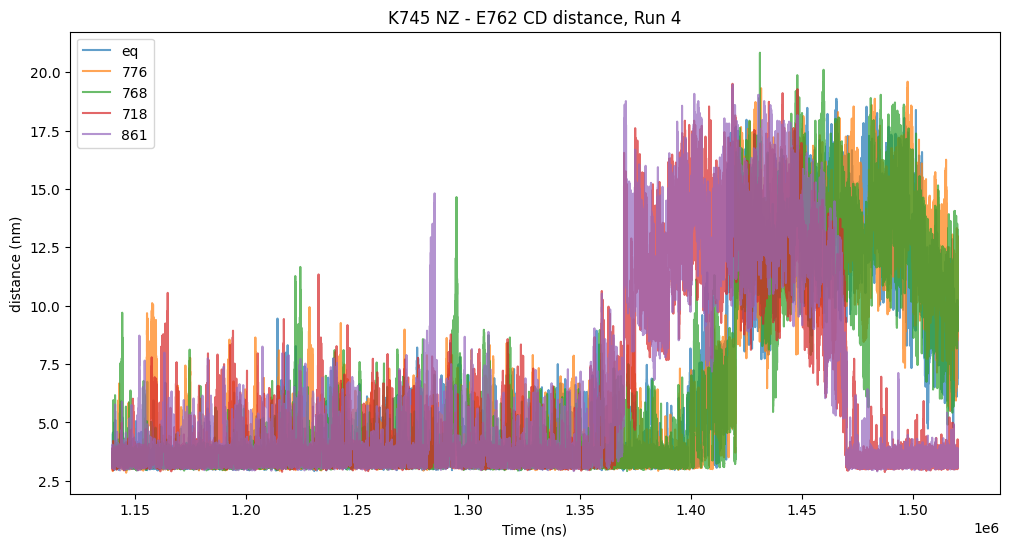

In [15]:
#MORE SALT BRIDGE STUFF



plt.figure(figsize=(12,6))
plt.plot(sb_df_full[0][Run_4], sb_df_full[1][Run_4]*10, label = "eq", alpha = 0.7)
plt.plot(sb_df_776[0][Run_4], sb_df_776[1][Run_4]*10, label = "776", alpha = 0.7)
plt.plot(sb_df_768[0][Run_4], sb_df_768[1][Run_4]*10, label = "768", alpha = 0.7)
plt.plot(sb_df_718[0][Run_4], sb_df_718[1][Run_4]*10, label = "718", alpha = 0.7)
plt.plot(sb_df_861[0][Run_4], sb_df_861[1][Run_4]*10, label = "861", alpha = 0.7)

plt.title("K745 NZ - E762 CD distance, Run 4")
plt.xlabel("Time (ns)")
plt.ylabel("distance (nm)")



plt.legend()

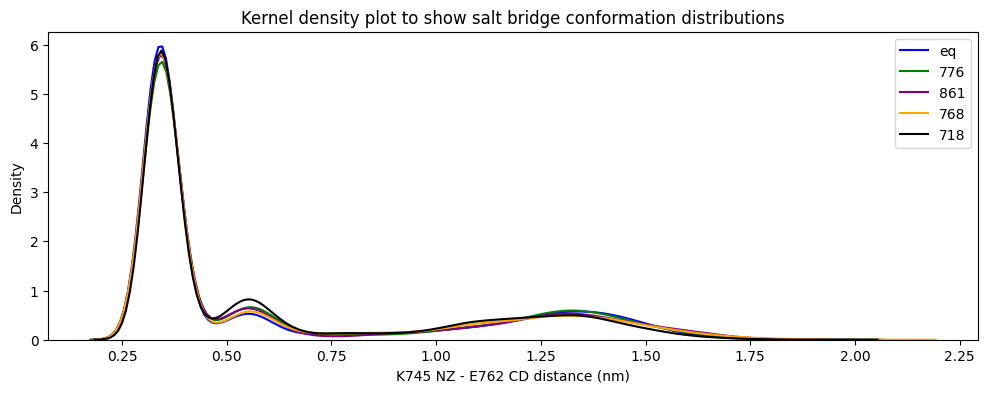

In [16]:
plt.figure(figsize=(12,4))
sns.kdeplot(data=sb_df_full[1][Run_4], color="blue", label = "eq")
sns.kdeplot(data=sb_df_776[1][Run_4], color="green", label = "776")
sns.kdeplot(data=sb_df_861[1][Run_4], color="purple", label = "861")
sns.kdeplot(data=sb_df_768[1][Run_4], color="orange", label = "768")
sns.kdeplot(data=sb_df_718[1][Run_4], color="black", label = "718")
# plt.xlim(0.2, 0.45)
plt.xlabel("K745 NZ - E762 CD distance (nm)")
plt.title("Kernel density plot to show salt bridge conformation distributions")
plt.legend()
plt.savefig("KDFplotfordistances.png")
plt.show()